<a href="https://colab.research.google.com/github/meganlynnesm/cdp-mapping-systems/blob/main/loading-visualising-data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [117]:
%pip install lonboard
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [118]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize
from palettable.colorbrewer.sequential import Oranges_9, YlGn_9
from matplotlib.patches import Patch
from lonboard import Map, PolygonLayer
from lonboard.colormap import apply_continuous_cmap

In [119]:
broadband = pd.read_csv(
    r"C:\Users\megan\OneDrive\Documents\CDP Mapping Systems\cdp-mapping-systems-main\content\Data\broadband_choice_speed_by_block.csv"
)
# inserting data to be read
# broadband in NYC

In [120]:
# checking data loaded
broadband.shape

(39148, 12)

In [121]:
# checking data loaded pt2
broadband.head()

,OID,BlockCode,GEO_ID,BCTCB2010,BoroCode,NTA Code,NTA Name,Borough,PUMA,Maximum Residential Broadband Speed by Block,Residential ISP Count by Block,Commerical Fiber Count by Block
0,0,360610037001012,360610037001,10037001012,1,MN24,SoHo-TriBeCa-Civic Center-Little Italy,Manhattan,3810,"1,000",3.0,11.0
1,1,360610037002002,360610037002,10037002002,1,MN24,SoHo-TriBeCa-Civic Center-Little Italy,Manhattan,3810,"1,000",3.0,5.0
2,2,360610037003008,360610037003,10037003008,1,MN24,SoHo-TriBeCa-Civic Center-Little Italy,Manhattan,3810,940,2.0,6.0
3,3,360610037001000,360610037001,10037001000,1,MN24,SoHo-TriBeCa-Civic Center-Little Italy,Manhattan,3810,940,1.0,4.0
4,4,360610037001002,360610037001,10037001002,1,MN24,SoHo-TriBeCa-Civic Center-Little Italy,Manhattan,3810,940,2.0,4.0


In [122]:
# checking summary statistics
broadband[
    ["Residential ISP Count by Block", "Commerical Fiber Count by Block"]
].describe()
# 'commerical' is misspelled in the column name, but I will keep it as is to avoid errors when referencing the column later.

,Residential ISP Count by Block,Commerical Fiber Count by Block
count,37918.000000,37918.000000
mean,1.918719,1.518988
std,0.553909,1.097627
min,1.000000,0.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,5.000000,14.000000


In [123]:
# checking value counts for broadband speed by block
broadband["Maximum Residential Broadband Speed by Block"].value_counts(dropna=False)

Maximum Residential Broadband Speed by Block
940      32274
500       2963
1,000     2681
NaN       1230
Name: count, dtype: int64

In [124]:
# I can see many NaN values; so not certain if it means
# no broadband available or if the data is missing.
# I will check the data dictionary to see if it clarifies what NaN means in this context.

Text(0.5, 1.0, 'Broadband choice across NYC census blocks')

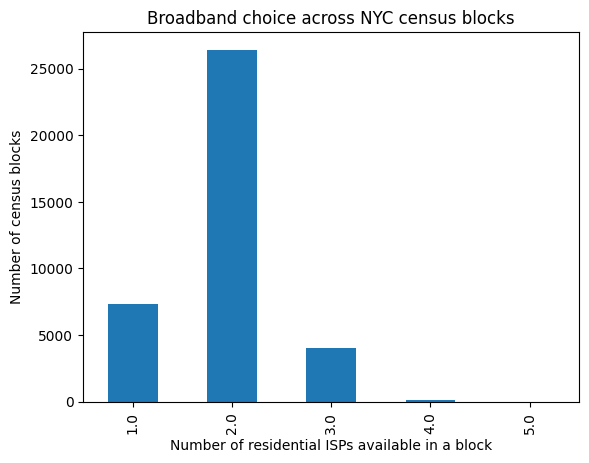

In [125]:
broadband["Residential ISP Count by Block"].value_counts().sort_index().plot.bar()
plt.xlabel("Number of residential ISPs available in a block")
plt.ylabel("Number of census blocks")
plt.title("Broadband choice across NYC census blocks")

In [126]:
# from the histogram I can see most blocks only have 1-2 broadband providers available, and a few blocks have 3-4 providers.
# There are also some blocks with 0 providers, which is concerning (relating to the NaN values I saw earlier).

In [127]:
broadband["Residential ISP Count by Block"].min()

np.float64(1.0)

In [128]:
# Tha above shows that there are blocks with 0 providers reported

## Data source, meaning & limitations

**Dataset:** Internet Master Plan — Broadband Choice and Speed by Census Block (2020),
NYC Mayor's Office of the CTO.
**Underlying source:** FCC Form 477 (June 2019). "Broadband" = the FCC standard of
≥ 25 Mbps download / 3 Mbps upload.
**Unit of analysis:** one row per 2010 census block.

### Attribute in focus
**Residential Broadband ISP Count by Block** — *"the number of residential broadband
internet service providers reported to be available per census block."*

> _Why I chose it:_ TODO — 1–2 sentences on why "broadband choice" matters to your
> project (the digital divide / who has options and who doesn't).

### What this attribute CAN tell us
- TODO
- TODO

### What this attribute CANNOT tell us
The dictionary itself carries this FCC warning:

> "A provider that reports deployment of a particular technology and bandwidth in a
> particular census block may not necessarily offer that particular service everywhere
> in the census block. Accordingly, a list of providers deployed in a census block does
> not necessarily reflect the number of choices available to any particular household or
> business location in that block, and the number of such providers in the census block
> does not purport to measure competition."



### Missing values
The dictionary's template asks contributors to state "how to interpret null/zero values,"
but the ISP-count row leaves that blank. In the data the count never drops below 1
(no zeros), so a null appears to mean *"no residential provider reported."*

## I used `fillna(0)` to acknoledge the data is potentially incomplete, I don't want to erase it completely.

### Geographic caveat
When I joined block-level data up to block-group geometry, ~13% of block groups didn't
match (mostly block group "0" — water / unpopulated areas the demographic file omits).


In [129]:
data_dict = pd.read_excel(
    r"C:\Users\megan\Downloads\Internet_Master_Plan_BROADBAND_CHOICE_AND_SPEED-BY-CENSUS-BLOCK-2020_DataDictionary.xlsx",
    sheet_name="Data Dictionary",
)
data_dict

,Data Dictionary - Column Information,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,Column Name,Column Description,"Term, Acronym, or Code Definitions","Additional Notes \n(where applicable, include ...",Type
1,OID,Origin Identification Number.,NaN,NaN,Text
2,BlockCode,The 2010 census block that the attribute or as...,NaN,NaN,#
3,GEO_ID,Geographic identifier.,GEOIDs are numeric codes that uniquely identif...,NaN,#
4,BCTCB2010,"Merged string value of the BoroCode, census tr...",NaN,NaN,#
5,BoroCode,Single digit unique identifier of a borough.,"Boro code (1 = Manhattan, 2 = Bronx, 3 = Brook...",NaN,#
6,Neighborhood Tabulation Area Code (NTA CODE),Four (4) digit code assigned to neighborhoods ...,The first two letters of each code represent t...,"Neighborhood Tabulation Areas, or NTAs, are ag...",Text
7,Neighborhood Tabulation Area Name (NTA NAME),Neighborhood name identifiers to differentiate...,NaN,"Neighborhood Tabulation Areas, or NTAs, are ag...",Text
8,Borough Name,The Borough of New York City where the attribu...,NaN,NaN,Text
9,PUMA,"A Public Use Microdata Area, or PUMA, are geog...",Public Use Microdata Area.,"A Public Use Microdata Area, or PUMA, are made...",#


In [130]:
xls = pd.ExcelFile(
    r"C:\Users\megan\Downloads\Internet_Master_Plan_BROADBAND_CHOICE_AND_SPEED-BY-CENSUS-BLOCK-2020_DataDictionary.xlsx"
)
xls.sheet_names  # list of sheet names

['Data Dictionary', 'Dataset Info']

In [131]:
# aggregate blocks to join to the geometry
broadband["bg_geoid"] = broadband["GEO_ID"].astype(str).str.zfill(12)

block_group = (
    broadband.groupby("bg_geoid")
    .agg(
        mean_isp_count=("Residential ISP Count by Block", "mean"),
        min_isp_count=("Residential ISP Count by Block", "min"),
        mean_fiber_count=("Commerical Fiber Count by Block", "mean"),
        n_blocks=("BlockCode", "size"),
    )
    .reset_index()
)
block_group.head()

,bg_geoid,mean_isp_count,min_isp_count,mean_fiber_count,n_blocks
0,360050001000,NaN,NaN,NaN,2
1,360050001001,1.000000,1.0,0.000000,25
2,360050002000,2.000000,2.0,1.000000,1
3,360050002001,1.833333,1.0,1.500000,6
4,360050002002,1.909091,1.0,1.545455,11


In [132]:
# load geometry and build join key
census = gpd.read_file("../Data/census_nyc_sp.fgb")

# Build the 12-digit block-group GEOID from the NHGIS GISJOIN code
gj = census["GISJOIN"].astype(str)
census["bg_geoid"] = gj.str[1:3] + gj.str[4:7] + gj.str[8:15]
census[["GISJOIN", "bg_geoid"]].head()

,GISJOIN,bg_geoid
0,G36008101010021,360811010021
1,G36008101010022,360811010022
2,G36008101010043,360811010043
3,G36008101010042,360811010042
4,G36008101010032,360811010032


In [133]:
# join and checking the matched data
bb_map = census.merge(block_group, on="bg_geoid", how="inner")
print(f"{len(bb_map)} of {len(block_group)} broadband block groups matched to geometry")

5769 of 6494 broadband block groups matched to geometry


<Axes: >

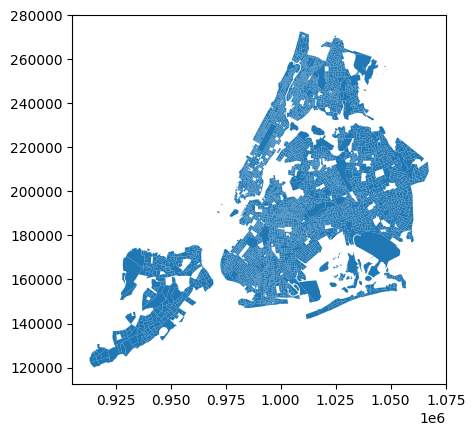

In [134]:
# load map
bb_map.plot()

c:\Users\megan\anaconda3\envs\cdp\Lib\site-packages\mapclassify\classifiers.py:1767: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 3.
  self.bins = quantile(y, k=k)


Text(0.5, 1.0, 'Average residential ISP count per block group')

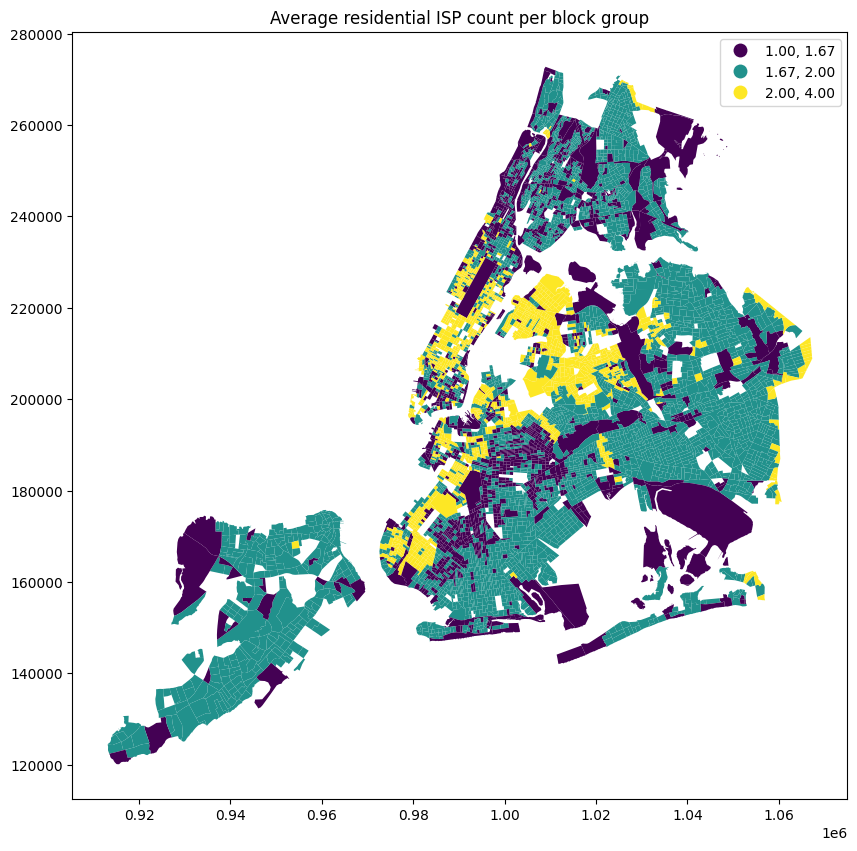

In [135]:
# mapping a chloropleth of the average residential ISP count per block group
bb_map.plot(
    column="mean_isp_count",
    figsize=(10, 10),
    legend=True,
    scheme="quantiles",
)
plt.title("Average residential ISP count per block group")

In [136]:
# above we can see the majority of brooklyn have 1-2 providers, while the majority of manhattan, queens and the bronx have 2-3 providers. Staten Island has a mix of 1-3 providers.

Text(0.5, 1.0, 'Fewest ISPs available in any block within each block group')

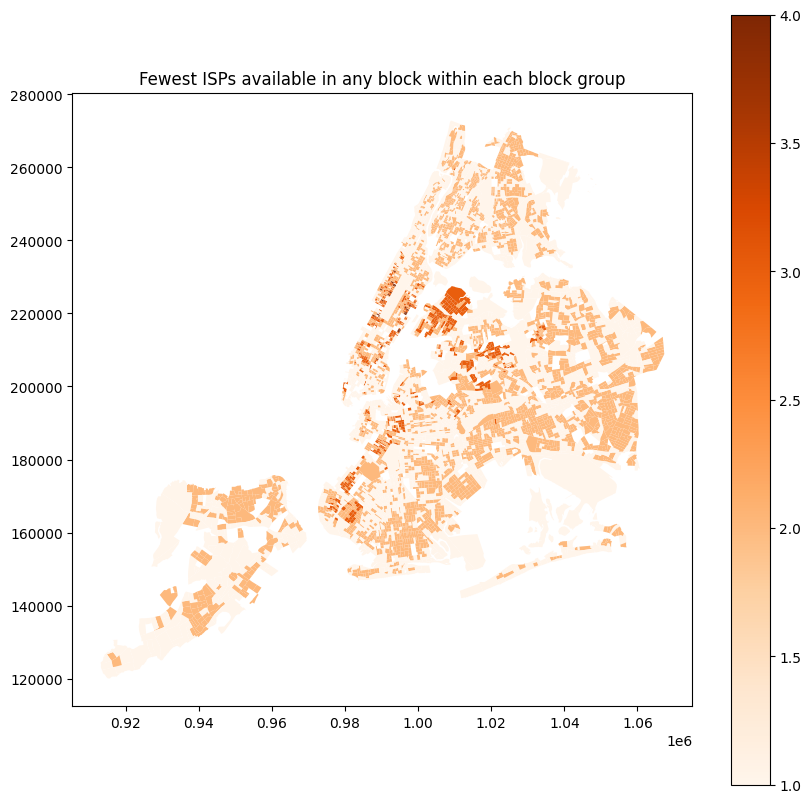

In [137]:
# mapping a chloropleth of the fewest residential ISP count per block group
bb_map.plot(column="min_isp_count", figsize=(10, 10), legend=True, cmap="Oranges")
plt.title("Fewest ISPs available in any block within each block group")

Text(0.5, 1.0, 'Average residential ISP count per census tract')

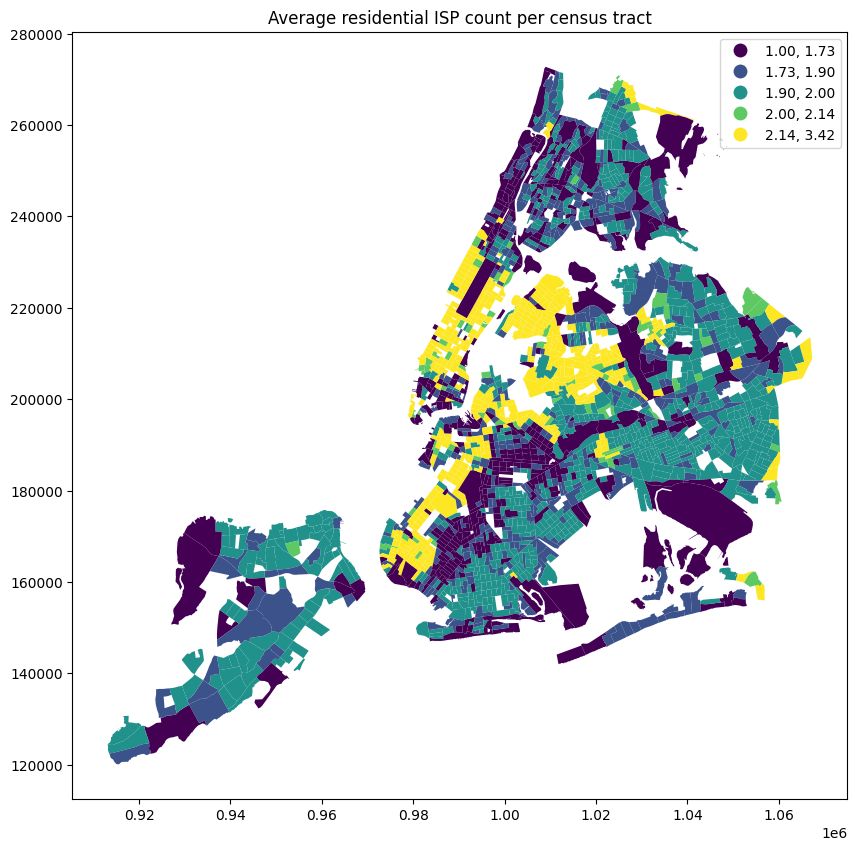

In [138]:
bb_map["tract_geoid"] = bb_map["bg_geoid"].str[:11]
tract = bb_map.dissolve(
    by="tract_geoid", aggfunc={"mean_isp_count": "mean", "n_blocks": "sum"}
)
tract.plot(column="mean_isp_count", figsize=(10, 10), legend=True, scheme="quantiles")
plt.title("Average residential ISP count per census tract")

Text(0.5, 1.0, 'Residential choice vs. commercial fibre by block group')

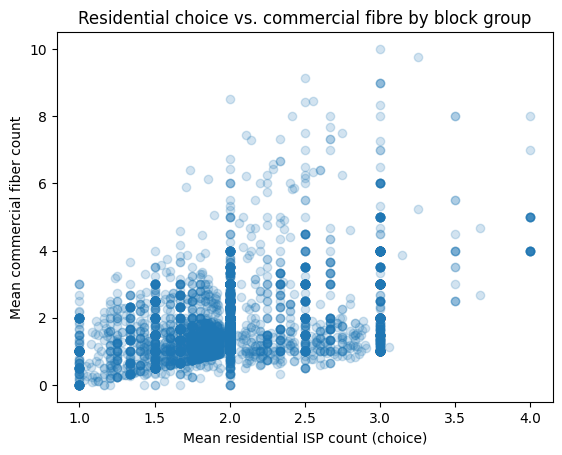

In [139]:
plt.scatter(bb_map["mean_isp_count"], bb_map["mean_fiber_count"], alpha=0.2)
plt.xlabel("Mean residential ISP count (choice)")
plt.ylabel("Mean commercial fiber count")
plt.title("Residential choice vs. commercial fibre by block group")

In [140]:
# Most block groups have 1-2 residential ISPs and 0-1 commercial fiber providers.
# There are a few block groups with 3-4 residential ISPs and 2-3 commercial fiber providers.
# A typical block group has little residential choice and little commercial fiber availability.
# There are a few block groups with high residential choice and high commercial fiber availability, but they are outliers.

In [141]:
# Following tutorial to create the 3D map of the average residential ISP count per block group
gdf3d = bb_map[["bg_geoid", "mean_isp_count", "geometry"]].copy()
vals = np.nan_to_num(gdf3d["mean_isp_count"].to_numpy(), nan=0)

colors = apply_continuous_cmap(Normalize(vals.min(), vals.max())(vals), Oranges_9)

layer = PolygonLayer.from_geopandas(
    gdf=gdf3d,
    extruded=True,
    get_elevation=vals * 500,
    get_fill_color=colors,
    wireframe=True,
)
Map(
    layer,
    view_state={
        "longitude": -73.98,
        "latitude": 40.73,
        "zoom": 9.2,
        "pitch": 45,
        "bearing": 0,
    },
)

c:\Users\megan\anaconda3\envs\cdp\Lib\site-packages\lonboard\_geoarrow\ops\reproject.py:116: UserWarning: Input being reprojected to EPSG:4326 CRS.
Lonboard is only able to render data in EPSG:4326 projection.
  warnings.warn(


In [142]:
# This representation isn't the best for ISP count, as it is difficult to see the differences in height between block groups with 1-2 ISPs.
# A better representation might be to use color to represent ISP count, rather than height.

In [143]:
# I was also curious about broadband speed in the area
# I wanted to visualise that next and see if there were outliers
# Or if for a city, everything was relatively uniform

In [144]:
# the speed column above is stored as text with a comma, so I will convert it to a float for analysis
broadband["speed_mbps"] = (
    broadband["Maximum Residential Broadband Speed by Block"]
    .str.replace(",", "", regex=False)  # "1,000" -> "1000"
    .astype(float)  # -> 1000.0 ; NaN stays NaN
)

In [145]:
# adding to block aggregation
block_group = (
    broadband.groupby("bg_geoid")
    .agg(
        mean_isp_count=("Residential ISP Count by Block", "mean"),
        max_speed=("speed_mbps", "max"),  # best speed available in the block group
        mean_fiber_count=("Commerical Fiber Count by Block", "mean"),
        n_blocks=("BlockCode", "size"),
    )
    .reset_index()
)

Text(0.5, 1.0, 'Maximum advertised broadband speed across NYC blocks')

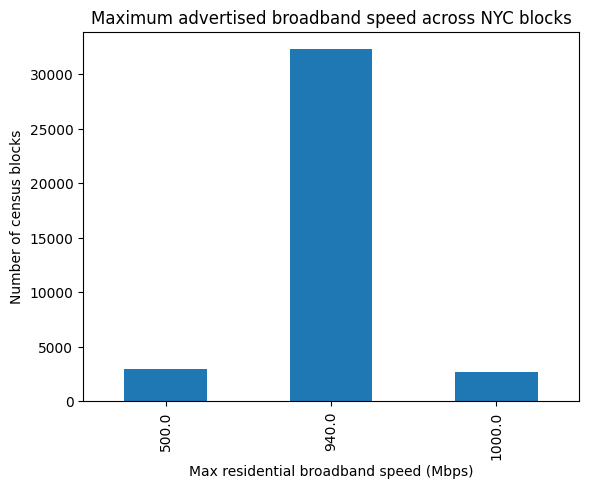

In [146]:
# adding a histogram
broadband["speed_mbps"].value_counts().sort_index().plot.bar()
plt.xlabel("Max residential broadband speed (Mbps)")
plt.ylabel("Number of census blocks")
plt.title("Maximum advertised broadband speed across NYC blocks")

In [147]:
# the range of values is small, as it is only the maximum advertised speed.
# I can't see the actual speeds which is a bit frustrating, but I can see that the majority of blocks have a maximum speed of 1000 Mbps,
# with a few blocks having 2000 Mbps and 500 Mbps.

In [148]:
block_group = (
    broadband.groupby("bg_geoid")
    .agg(
        mean_isp_count=("Residential ISP Count by Block", "mean"),
        max_speed=("speed_mbps", "max"),  # best speed available in the block group
        mean_fiber_count=("Commerical Fiber Count by Block", "mean"),
        n_blocks=("BlockCode", "size"),
    )
    .reset_index()
)

In [153]:
bb_map = census.merge(block_group, on="bg_geoid", how="inner")
print(f"{len(bb_map)} of {len(block_group)} broadband block groups matched to geometry")

5769 of 6494 broadband block groups matched to geometry


<Axes: >

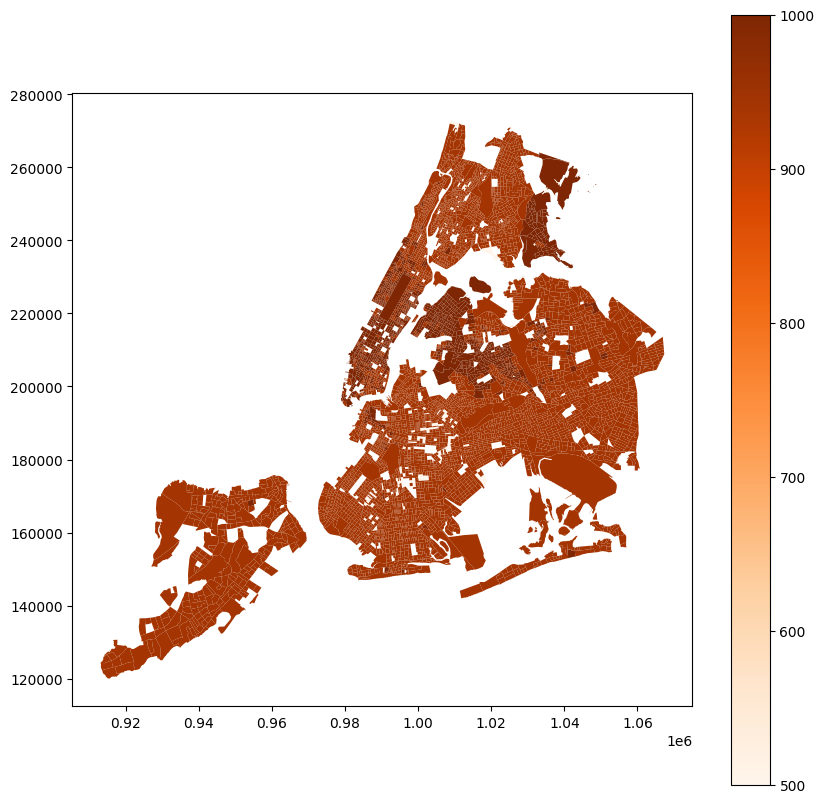

In [154]:
bb_map.plot(column="max_speed", figsize=(10, 10), legend=True, cmap="Oranges")

In [ ]:
# As predicted in the histogram, there is not a lot of
# variation visually.
# I looked for a differend dataset in relation to broadband speed,
# as I'm more interested in representing the actual speeds available,
# rather than the maximum advertised speed.

In [ ]:
# I found a different dataset that explores the homes which have
# adopted the broadband service, which is more interesting to me

In [155]:
adoption = pd.read_csv(
    r"C:\\Users\\megan\\OneDrive\\Documents\\CDP Mapping Systems\\cdp-mapping-systems-main\\content\\Data\\broadband_adoption_by_nta.csv"
)
adoption.shape  # (195, 77)  -> 195 neighborhoods, 77 columns

(195, 77)

In [156]:
adoption.head()

,Neighborhood Tabulation Area Code (NTA Code),Neighborhood Tabulation Area Name (NTA NAME),Borough Name,Total Population,Population Density (per Sq. Mi.),Total Number of Households,Area (Sq. Mi.),Street Mileage,Home Broadband Adoption (Percentage of Households),"Home Broadband Adoption by Quartiles (High, Medium-High, Medium-Low, Low)",...,"Indoor Cabling for Multiple Dwelling Units, Estimated Relative Costs",Optimal for Unlicensed\nMillimeter Wave Fixed Wireless Access as a Residential\nBroadband Solution,Percentage Optimal for Unlicensed\nMillimeter Wave Fixed Wireless Access as a Residential\nBroadband Solution,Estimated number of radio sites for CBRS coverage,Estimated number of radio sites for mmWave coverage in optimal areas,Sample of NTA Field Surveyed? (Y/N),Reviewed for Underground Fiber-to-the-Premise? (Y/N),Reviewed for Aerial Fiber-to-the-Premise? (Y/N),Reviewed for Millimeter Wave Fixed Wireless Access? (Y/N),Field Survey Findings
0,BK09,Brooklyn Heights-Cobble Hill,Brooklyn,"23,758","65,994.44","11,150",0.36,19,86.4%,High Connected,...,Low,YES,37%,174.0,39.0,NO,NO,NO,NO,NONE
1,BK17,Sheepshead Bay-Gerritsen Beach-Manhattan Beach,Brooklyn,"65,167","28,707.93","25,483",2.27,80,77.29%,Medium High Connected,...,Average,YES,25%,86.0,29.0,NO,NO,NO,NO,NONE
2,BK19,Brighton Beach,Brooklyn,"34,814","56,151.61","14,441",0.62,23,66.53%,Medium Low Connected,...,Low,YES,62%,56.0,8.0,NO,NO,NO,NO,NONE
3,BK21,Seagate-Coney Island,Brooklyn,"31,120","22,388.49","11,553",1.39,25,55.47%,Low Connected,...,Average,YES,36%,82.0,0.0,YES,NO,YES,YES,Low make-ready requirements. Some locations ha...
4,BK23,West Brighton,Brooklyn,"17,252","55,651.61","8,547",0.31,12,66.82%,Medium Low Connected,...,Low,YES,37%,185.0,35.0,NO,NO,NO,NO,NONE


In [157]:
# lots of columns — consolidating the ones I'm interested in
adoption[
    [
        "Neighborhood Tabulation Area Name (NTA NAME)",
        "Borough Name",
        "Home Broadband Adoption (Percentage of Households)",
        "Mobile Dependent Households (Percentage of Households)",
    ]
].head()

,Neighborhood Tabulation Area Name (NTA NAME),Borough Name,Home Broadband Adoption (Percentage of Households),Mobile Dependent Households (Percentage of Households)
0,Brooklyn Heights-Cobble Hill,Brooklyn,86.4%,5%
1,Sheepshead Bay-Gerritsen Beach-Manhattan Beach,Brooklyn,77.29%,7%
2,Brighton Beach,Brooklyn,66.53%,8%
3,Seagate-Coney Island,Brooklyn,55.47%,10%
4,West Brighton,Brooklyn,66.82%,9%


In [158]:
# cleaning the attricbutes for the join
adoption["home_adoption"] = pd.to_numeric(
    adoption["Home Broadband Adoption (Percentage of Households)"]
    .str.replace("%", "", regex=False)
    .str.replace(",", "", regex=False),
    errors="coerce",
)

adoption["mobile_dependent"] = pd.to_numeric(
    adoption["Mobile Dependent Households (Percentage of Households)"].str.replace(
        "%", "", regex=False
    ),
    errors="coerce",
)

adoption[["home_adoption", "mobile_dependent"]].describe()

,home_adoption,mobile_dependent
count,195.000000,195.000000
mean,68.963179,9.153846
std,14.197798,4.570967
min,0.000000,0.000000
25%,62.080000,6.000000
50%,71.880000,8.000000
75%,77.375000,11.000000
max,100.000000,28.000000


In [ ]:
# above, I added errors="coerce" to the pd.to_numeric() function to handle any non-numeric values that may be present in the columns.
# This will convert any non-numeric values to NaN, allowing for a cleaner analysis of the data.

Text(0.5, 1.0, 'Home broadband adoption across NYC neighborhoods')

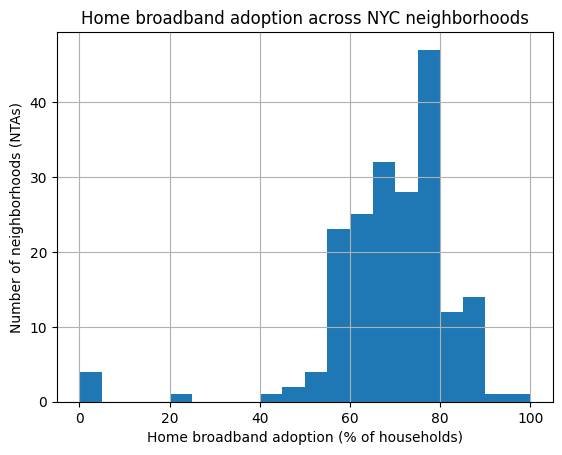

In [ ]:
# creating histogram
adoption["home_adoption"].hist(bins=20)
plt.xlabel("Home broadband adoption (% of households)")
plt.ylabel("Number of neighborhoods (NTAs)")
plt.title("Home broadband adoption across NYC neighborhoods")

(195, 9)


<Axes: >

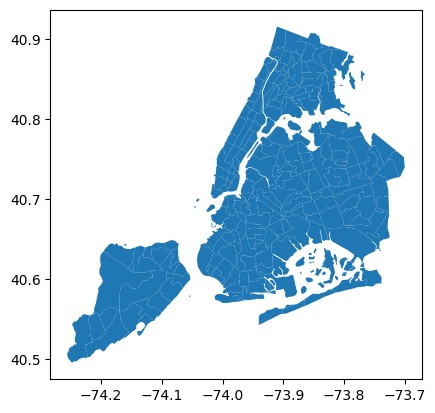

In [ ]:
# loading NYC geometry
nta = gpd.read_file("../Data/nta_2010.geojson")
print(nta.shape)
nta.plot()

In [162]:
nta_map = nta.merge(
    adoption,
    left_on="NTACode",
    right_on="Neighborhood Tabulation Area Code (NTA Code)",
    how="left",
)
print(
    nta_map["home_adoption"].notna().sum(),
    "of",
    len(nta_map),
    "neighborhoods have data",
)

195 of 195 neighborhoods have data


Text(0.5, 1.0, 'Home broadband adoption by neighborhood')

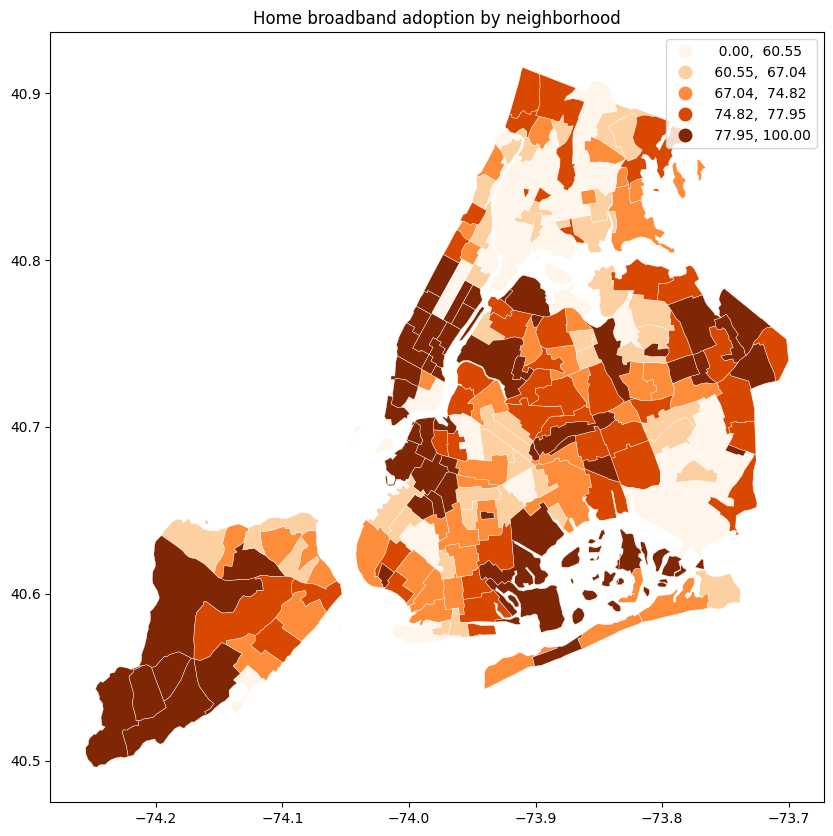

In [163]:
nta_map.plot(
    column="home_adoption",
    figsize=(10, 10),
    legend=True,
    scheme="quantiles",
    cmap="Oranges",
    edgecolor="white",
    linewidth=0.3,
)
plt.title("Home broadband adoption by neighborhood")

In [ ]:
# We can see from the map above the majority of neighborhoods have a home broadband adoption rate of 60-80%, with a few neighborhoods having a rate of 80-100%.
# There are also a few neighborhoods with a rate of 40-60%, and a few neighborhoods with a rate of 20-40%.
# There are no neighborhoods with a rate of 0-20%.

Text(0.5, 1.0, '% of blocks with ≥900 Mbps available')

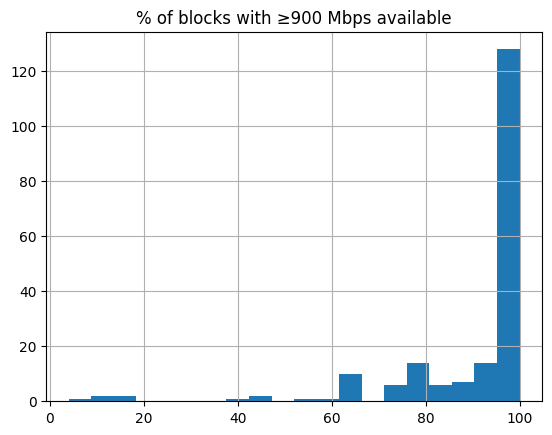

In [164]:
adoption["speed_900"] = pd.to_numeric(
    adoption[
        "Percentage of Blocks with ISP Reported Speed Availability of >=900 Mbps"
    ].str.replace("%", "", regex=False),
    errors="coerce",
)
adoption["speed_900"].hist(bins=20)
plt.title("% of blocks with ≥900 Mbps available")

Text(0.5, 1.0, 'Adoption vs. mobile dependence by neighborhood')

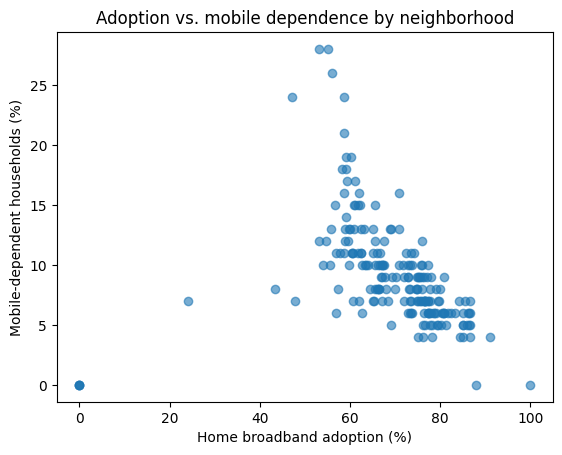

In [165]:
# comparing attributes
plt.scatter(nta_map["home_adoption"], nta_map["mobile_dependent"], alpha=0.6)
plt.xlabel("Home broadband adoption (%)")
plt.ylabel("Mobile-dependent households (%)")
plt.title("Adoption vs. mobile dependence by neighborhood")

In [166]:
nta_map[["home_adoption", "mobile_dependent"]].corr()

,home_adoption,mobile_dependent
home_adoption,1.000000,-0.229053
mobile_dependent,-0.229053,1.000000


In [167]:
from matplotlib.colors import Normalize
from palettable.colorbrewer.sequential import Oranges_9
from lonboard import Map, PolygonLayer
from lonboard.colormap import apply_continuous_cmap

In [169]:
g3d = nta_map[["NTACode", "home_adoption", "geometry"]].copy()
vals = np.nan_to_num(g3d["home_adoption"].to_numpy(), nan=0)
colors = apply_continuous_cmap(Normalize(vals.min(), vals.max())(vals), Oranges_9)
layer = PolygonLayer.from_geopandas(
    g3d, extruded=True, get_elevation=vals * 30, get_fill_color=colors, wireframe=True
)
Map(
    layer,
    view_state={
        "longitude": -73.98,
        "latitude": 40.73,
        "zoom": 9.2,
        "pitch": 45,
        "bearing": 0,
    },
)

In [ ]:
# I though the 2D map was the most visually effective,
# as it was easier to see the differences in adoption rates
# between neighborhoods.
# The 3D map was interesting, but it was more difficult to interpret the data.
# I think a hex map would be a good way to represent the data, as it would allow for a more uniform representation of the neighborhoods,
# and would make it easier to see the differences in adoption rates between neighborhoods.
# However I am working with polygons, so a hex map would be difficult to create.

In [170]:
# EXTRA
# Testing to see if I can create the hex map
import h3
from shapely.geometry import Polygon

In [173]:
RES = 9  # hex size: 7 = coarser, 9 = finer. 8 ≈ 0.7 km² per hex

records = []
for _, row in nta_map.iterrows():
    geom = row.geometry
    if geom is None:
        continue
    val = row["home_adoption"]
    polys = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
    for poly in polys:
        outer = [
            (y, x) for x, y in poly.exterior.coords
        ]  # h3 wants (lat, lng); shapely is (lng, lat)
        shape = h3.LatLngPoly(outer)
        for cell in h3.h3shape_to_cells(shape, RES):
            records.append((cell, val))

hexdf = pd.DataFrame(records, columns=["cell", "home_adoption"]).drop_duplicates("cell")


def cell_poly(cell):
    b = h3.cell_to_boundary(cell)  # [(lat, lng), ...]
    return Polygon([(lng, lat) for lat, lng in b])  # back to (lng, lat) for shapely


hexgdf = gpd.GeoDataFrame(
    hexdf, geometry=[cell_poly(c) for c in hexdf["cell"]], crs="EPSG:4326"
)
hexgdf.shape  # ~ (1052, 3)

(7412, 3)

Text(0.5, 1.0, 'Home broadband adoption — H3 hex grid')

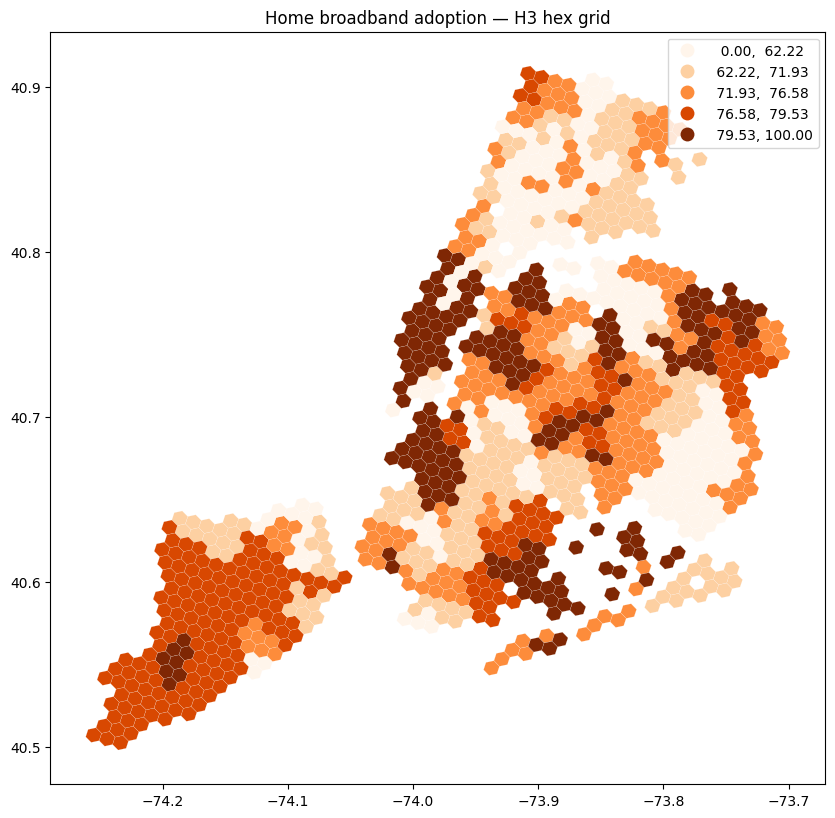

In [172]:
hexgdf.plot(
    column="home_adoption",
    figsize=(10, 10),
    legend=True,
    scheme="quantiles",
    cmap="Oranges",
    edgecolor="white",
    linewidth=0.1,
)
plt.title("Home broadband adoption — H3 hex grid")

In [174]:
# I used an AI agent to help write the code to transform the polygons
# into something translatable for the hex map.
# It's not necessarily better than expected for this specific dataset,
# but there was no harm in testing out the approach.